[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/next-gen-aiam/blob/rl/foundation/notebooks/04g_rl_ppo.ipynb)

# Notebook 04g — RL PPO Armor Run (Session 4d)

PPO (Proximal Policy Optimization) on the full 29-asset universe with monthly walk-forward refit.  
One config: λ_risk = 0.02 (matches REINFORCE baseline).  
Key question: does PPO — a stronger on-policy actor-critic — escape the static collapse  
observed with REINFORCE at N=29, or reproduce it? Expected outcome: reproduces it.  
Either way, the result is the finding.

**Design**:
- Clipped surrogate objective (clip_eps=0.2)
- GAE advantage (λ=0.95, γ=0.95)
- K=4 epochs per batch, minibatch_size=32
- entropy_coef=0.01, grad_clip=1.0, lr=3e-4
- Checkpointing after each (refit, seed) to survive runtime kill

In [1]:
!nvidia-smi

Wed May 20 22:48:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys, os, time, warnings
from pathlib import Path

IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print('Detected Colab — cloning repo...')
    os.system('git clone -b rl/foundation https://github.com/FranQuant/next-gen-aiam.git 2>&1 | tail -3')
    os.chdir('next-gen-aiam')
    print(f'Working dir: {os.getcwd()}')
    print('Installing dependencies...')
    os.system('pip install -q -e . 2>&1 | tail -3')
    os.system('pip install -q pyarrow scipy scikit-learn cvxpy pandas matplotlib seaborn torch 2>&1 | tail -3')
else:
    print(f'Detected local environment — {os.getcwd()}')

Detected Colab — cloning repo...
Working dir: /content/next-gen-aiam
Installing dependencies...


## §1 Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})
warnings.filterwarnings('ignore')

ROOT = Path(os.getcwd())
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent

for p in [str(ROOT / 'src'), str(ROOT / 'notebooks')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from _shared import ann_sharpe, ann_return, ann_vol, max_drawdown, TRADING_DAYS
from aiam.data.split import TEST_START, TRAIN_END
from aiam.dl.walkforward import generate_refit_dates
from aiam.rl.env import PortfolioEnv
from aiam.rl.policy import SimplexPolicy
from aiam.rl.ppo import PPOConfig, train_ppo
from aiam.rl.walkforward import WalkForwardRLEnsemble, RLRefitResult, fit_walkforward_ppo

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## §2 Config

In [4]:
# -----------------------------------------------------------------------
# Set RUN_MODE = 'smoke' for a quick local sanity check (2 refits, 1 seed, 5 eps)
# Set RUN_MODE = 'full'  for the actual Colab G4 run (41 refits, 5 seeds, 200 eps)
# -----------------------------------------------------------------------
RUN_MODE = 'full'   # <-- change to 'smoke' for local testing

LAMBDA          = 0.02
HIDDEN_DIM      = 32
TRAIN_WINDOW_MONTHS = 24
LOOKBACK        = 20

if RUN_MODE == 'smoke':
    EPISODES       = 5
    SEEDS          = [42]
    MAX_STEPS      = 60
    REFIT_SUBSET   = 2
else:
    EPISODES       = 200
    SEEDS          = [42, 43, 44, 45, 46]
    MAX_STEPS      = None   # full rollouts
    REFIT_SUBSET   = None   # all refits

FIG_DIR = ROOT / 'results' / 'rl' / 'n29_ppo' / 'figures'
CKPT_DIR = ROOT / 'results' / 'rl' / 'n29_ppo' / 'checkpoints'
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'RUN_MODE   : {RUN_MODE}')
print(f'Episodes   : {EPISODES}')
print(f'Seeds      : {SEEDS}')
print(f'Max steps  : {MAX_STEPS}')
print(f'Lambda risk: {LAMBDA}')

RUN_MODE   : full
Episodes   : 200
Seeds      : [42, 43, 44, 45, 46]
Max steps  : None
Lambda risk: 0.02


## §3 Data Loading — 29-Asset Returns

In [5]:
prices = pd.read_parquet(ROOT / 'data' / 'cache' / 'prices_29.parquet')
returns_all = prices.pct_change().dropna()

returns_train = returns_all.loc[:TRAIN_END]
returns_oos   = returns_all.loc[TEST_START:]
ASSETS   = returns_all.columns.tolist()
N_ASSETS = len(ASSETS)

print(f'Universe   : {N_ASSETS} assets')
print(f'Full period: {returns_all.index[0].date()} → {returns_all.index[-1].date()}  ({len(returns_all)} days)')
print(f'Train      : {returns_train.index[0].date()} → {returns_train.index[-1].date()}  ({len(returns_train)} days)')
print(f'OOS        : {returns_oos.index[0].date()} → {returns_oos.index[-1].date()}   ({len(returns_oos)} days)')

Universe   : 29 assets
Full period: 2007-04-12 → 2026-04-30  (4794 days)
Train      : 2007-04-12 → 2022-12-30  (3960 days)
OOS        : 2023-01-03 → 2026-04-30   (834 days)


## §4 Walk-Forward Setup

In [6]:
oos_start = pd.Timestamp(TEST_START)
oos_end   = returns_all.index[-1]

refit_dates = generate_refit_dates(
    test_start=oos_start,
    test_end=oos_end,
    cadence='monthly',
    calendar=returns_all.index,
)

if REFIT_SUBSET is not None:
    refit_dates = refit_dates[:REFIT_SUBSET]

total_fits = len(SEEDS) * len(refit_dates)
print(f'Refit dates : {len(refit_dates)}')
print(f'First refit : {refit_dates[0].date()}')
print(f'Last refit  : {refit_dates[-1].date()}')
print(f'Total fits  : {total_fits}  ({len(SEEDS)} seeds × {len(refit_dates)} refits)')
print(f'K epochs/fit: 4  →  effective gradient updates ≈ {total_fits * EPISODES * 4}')

Refit dates : 41
First refit : 2022-12-01
Last refit  : 2026-04-01
Total fits  : 205  (5 seeds × 41 refits)
K epochs/fit: 4  →  effective gradient updates ≈ 164000


## §5 PPO Training (λ_risk = 0.02)

In [7]:
config_PPO = PPOConfig(
    episodes=EPISODES,
    gamma=0.95,
    gae_lambda=0.95,
    clip_eps=0.2,
    k_epochs=4,
    minibatch_size=32,
    value_coef=0.5,
    lr=3e-4,
    entropy_coef=0.01,
    grad_clip=1.0,
    seed=0,
    max_steps_per_episode=MAX_STEPS,
)

print(f'PPO config: episodes={EPISODES}, clip_eps=0.2, k_epochs=4, lr=3e-4')
print(f'Checkpoint dir: {CKPT_DIR}')
t0 = time.time()

wf_PPO = fit_walkforward_ppo(
    returns=returns_all,
    refit_dates=refit_dates,
    config=config_PPO,
    seeds=SEEDS,
    hidden_dim=HIDDEN_DIM,
    training_window_months=TRAIN_WINDOW_MONTHS,
    lambda_risk=LAMBDA,
    checkpoint_dir=CKPT_DIR,
    verbose=True,
)

elapsed = time.time() - t0
print(f'\nPPO training done in {elapsed:.1f}s ({elapsed/60:.1f} min)')
ckpts_saved = list(CKPT_DIR.glob('*.pt'))
print(f'Checkpoints saved: {len(ckpts_saved)} files in {CKPT_DIR}')

PPO config: episodes=200, clip_eps=0.2, k_epochs=4, lr=3e-4
Checkpoint dir: /content/next-gen-aiam/results/rl/n29_ppo/checkpoints
  Refit  1/41: 2020-12-01 → 2022-11-30 (504 days) | seeds=5 | final_reward=-0.79464 | mean_to=1.8698 | 161.5s
  Refit  2/41: 2021-01-03 → 2023-01-02 (503 days) | seeds=5 | final_reward=-1.10923 | mean_to=1.8696 | 157.0s
  Refit  3/41: 2021-02-01 → 2023-01-31 (504 days) | seeds=5 | final_reward=-0.69567 | mean_to=1.8698 | 156.8s
  Refit  4/41: 2021-03-01 → 2023-02-28 (504 days) | seeds=5 | final_reward=-0.89949 | mean_to=1.8698 | 156.7s
  Refit  5/41: 2021-04-03 → 2023-04-02 (503 days) | seeds=5 | final_reward=-0.98941 | mean_to=1.8696 | 156.4s
  Refit  6/41: 2021-05-01 → 2023-04-30 (502 days) | seeds=5 | final_reward=-0.85985 | mean_to=1.8692 | 153.3s
  Refit  7/41: 2021-06-01 → 2023-05-31 (504 days) | seeds=5 | final_reward=-0.86033 | mean_to=1.8698 | 157.3s
  Refit  8/41: 2021-07-03 → 2023-07-02 (501 days) | seeds=5 | final_reward=-1.00527 | mean_to=1.8691

## §6 OOS Evaluation

In [8]:
print('Evaluating PPO OOS...')
ret_PPO, weights_PPO, diag_PPO = wf_PPO.evaluate_oos(
    returns_all, oos_start=oos_start, oos_end=oos_end, lookback=LOOKBACK
)

sharpe_PPO  = ann_sharpe(ret_PPO)
annret_PPO  = ann_return(ret_PPO)
annvol_PPO  = ann_vol(ret_PPO)
maxdd_PPO   = max_drawdown(ret_PPO)

print(f'\nPPO (λ=0.02): Sharpe={sharpe_PPO:.4f}  AnnRet={annret_PPO:.4f}  '
      f'AnnVol={annvol_PPO:.4f}  MaxDD={maxdd_PPO:.4f}')
print(f'ML bar (reference): 2.579  |  REINFORCE bar: 2.0255')
print(f'Gap PPO vs ML bar  : {sharpe_PPO - 2.579:.3f}')
print(f'Gap PPO vs REINFORCE: {sharpe_PPO - 2.0255:.3f}')

Evaluating PPO OOS...

PPO (λ=0.02): Sharpe=2.0267  AnnRet=0.2206  AnnVol=0.1009  MaxDD=-0.1216
ML bar (reference): 2.579  |  REINFORCE bar: 2.0255
Gap PPO vs ML bar  : -0.552
Gap PPO vs REINFORCE: 0.001


## §7 FEATURE_CONDITIONAL_CHECK Gate

**GATE**: if `mean_turnover < 0.05` AND `weight_std_across_time < 0.01`, PPO has collapsed  
to a near-static allocation — same as REINFORCE at N=29.

In [9]:
TO_THRESH   = 0.05
WSTD_THRESH = 0.01

mean_to_PPO = diag_PPO['mean_turnover']
wstd_PPO    = diag_PPO['weight_std_across_time']

collapsed_PPO = (mean_to_PPO < TO_THRESH) and (wstd_PPO < WSTD_THRESH)

print('=' * 60)
print('FEATURE_CONDITIONAL_CHECK')
print('=' * 60)
print(f'PPO mean_turnover          : {mean_to_PPO:.6f}  (threshold < {TO_THRESH})')
print(f'PPO weight_std_across_time : {wstd_PPO:.6f}  (threshold < {WSTD_THRESH})')
print()
if collapsed_PPO:
    print('VERDICT: STATIC_COLLAPSE_DETECTED')
    print('  PPO reproduces the static collapse at N=29.')
    print('  Consistent with REINFORCE. On-policy actor-critic does not escape')
    print('  the simplex collapse in this regime.')
else:
    print('VERDICT: DYNAMIC_POLICY_DETECTED')
    print('  PPO produced feature-conditional weights.')
    print(f'  OOS Sharpe {sharpe_PPO:.4f} vs REINFORCE 2.0255 (gap {sharpe_PPO - 2.0255:+.4f})')
print('=' * 60)

FEATURE_CONDITIONAL_CHECK
PPO mean_turnover          : 0.000007  (threshold < 0.05)
PPO weight_std_across_time : 0.000000  (threshold < 0.01)

VERDICT: STATIC_COLLAPSE_DETECTED
  PPO reproduces the static collapse at N=29.
  Consistent with REINFORCE. On-policy actor-critic does not escape
  the simplex collapse in this regime.


## §8 Training Diagnostics

In [10]:
diag_rows = []
for rr in wf_PPO.refit_results:
    for seed_idx, (agent, hist) in enumerate(zip(rr.agents, rr.histories)):
        seed = SEEDS[seed_idx]
        final_reward   = hist.episode_rewards[-1] if hist.episode_rewards else float('nan')
        mean_to_train  = float(np.mean(hist.mean_turnovers)) if hist.mean_turnovers else float('nan')
        last10_to      = float(np.mean(hist.mean_turnovers[-10:])) if hist.mean_turnovers else float('nan')
        mean_w         = hist.mean_weights[-1] if hist.mean_weights else np.full(N_ASSETS, float('nan'))
        w_std          = float(np.std(mean_w)) if not np.all(np.isnan(mean_w)) else float('nan')
        diag_rows.append({
            'refit_date':          rr.refit_date,
            'seed':                seed,
            'final_episode_reward': final_reward,
            'mean_turnover_train': mean_to_train,
            'last10ep_turnover':   last10_to,
            'final_weight_std':    w_std,
        })

diag_df = pd.DataFrame(diag_rows)
diag_path = ROOT / 'results' / 'rl' / 'n29_ppo' / 'diagnostics_ppo.parquet'
diag_df.to_parquet(diag_path)
print(f'Saved diagnostics: {diag_path}')
print(diag_df.describe().round(6).to_string())

Saved diagnostics: /content/next-gen-aiam/results/rl/n29_ppo/diagnostics_ppo.parquet
                          refit_date        seed  final_episode_reward  mean_turnover_train  last10ep_turnover  final_weight_std
count                            205  205.000000            205.000000           205.000000         205.000000        205.000000
mean   2024-08-01 09:21:57.073170688   44.000000             -0.757930             1.868906           1.869403          0.005844
min              2022-12-01 00:00:00   42.000000             -1.354675             1.867631           1.866763          0.004127
25%              2023-10-02 00:00:00   43.000000             -0.906550             1.867880           1.868204          0.005207
50%              2024-08-01 00:00:00   44.000000             -0.730698             1.868463           1.869246          0.005962
75%              2025-06-02 00:00:00   45.000000             -0.590255             1.870228           1.870461          0.006317
max         

## §9 Comparison Table → data/published/

In [11]:
# Load pre-populated comparison CSV (base 37 + 2 REINFORCE)
base_csv = ROOT / 'data' / 'published' / 'full_comparison_with_rl.csv'
base_df  = pd.read_csv(base_csv, index_col=0)
print(f'Base comparison: {len(base_df)} strategies')

def _rl_row(ret_series, family):
    return {
        'Ann Ret': ann_return(ret_series),
        'Ann Vol': ann_vol(ret_series),
        'Sharpe':  ann_sharpe(ret_series),
        'Max DD':  max_drawdown(ret_series),
        'Family':  family,
    }

ppo_row = pd.DataFrame(
    [_rl_row(ret_PPO, 'RL (PPO)')],
    index=['RL(PPO,lam=0.02)'],
)

# Remove any stale PPO rows, then append fresh one
non_ppo = base_df[~base_df.index.str.startswith('RL(PPO')]
full_df  = pd.concat([non_ppo, ppo_row]).sort_values('Sharpe', ascending=False)

published_csv = ROOT / 'data' / 'published' / 'full_comparison_with_rl.csv'
full_df.to_csv(published_csv)
print(f'Saved: {published_csv}  ({len(full_df)} rows)')

# Copy to results for artifact zip
results_csv = ROOT / 'results' / 'rl' / 'n29_ppo' / 'full_comparison_with_rl.csv'
full_df.to_csv(results_csv)

# Top-10 + RL/PPO ranks
print('\nTop-10:')
print(full_df.head(10)[['Sharpe', 'Family']].to_string())
print()
all_idx  = list(full_df.index)
rl_rows  = [i for i in all_idx if i.startswith('RL')]
for row_name in rl_rows:
    rank = all_idx.index(row_name) + 1
    sh   = full_df.loc[row_name, 'Sharpe']
    fam  = full_df.loc[row_name, 'Family']
    print(f'  {row_name:30s}: Sharpe={sh:.4f}  Rank={rank}/{len(full_df)}  ({fam})')

Base comparison: 39 strategies
Saved: /content/next-gen-aiam/data/published/full_comparison_with_rl.csv  (40 rows)

Top-10:
                                   Sharpe                  Family
MSR(Ensemble_μ̂)                 2.579464           ML (ensemble)
VMP(MDP(LW))                     2.422222               Classical
MSR(RF_μ̂)                       2.394467         ML (single-fit)
MSR(MLP_μ̂)                      2.385701         DL (single-fit)
SignalTilt(XGB)                  2.304062         ML (single-fit)
VMP(SignalTilt(XGB))             2.292478                ML + VMP
MSR(Lasso_μ̂)                    2.271516         ML (single-fit)
SignalTilt(Transformer)          2.270855         DL (single-fit)
MSR(Transformer_μ̂)              2.268268         DL (single-fit)
SignalTilt(EnsembleDL_weighted)  2.265787  DL (weighted ensemble)

  RL(PPO,lam=0.02)              : Sharpe=2.0267  Rank=26/40  (RL (PPO))
  RL(REINFORCE,lam=0.00)        : Sharpe=2.0256  Rank=27/40  (RL (REINFORCE))

## §10 Figures

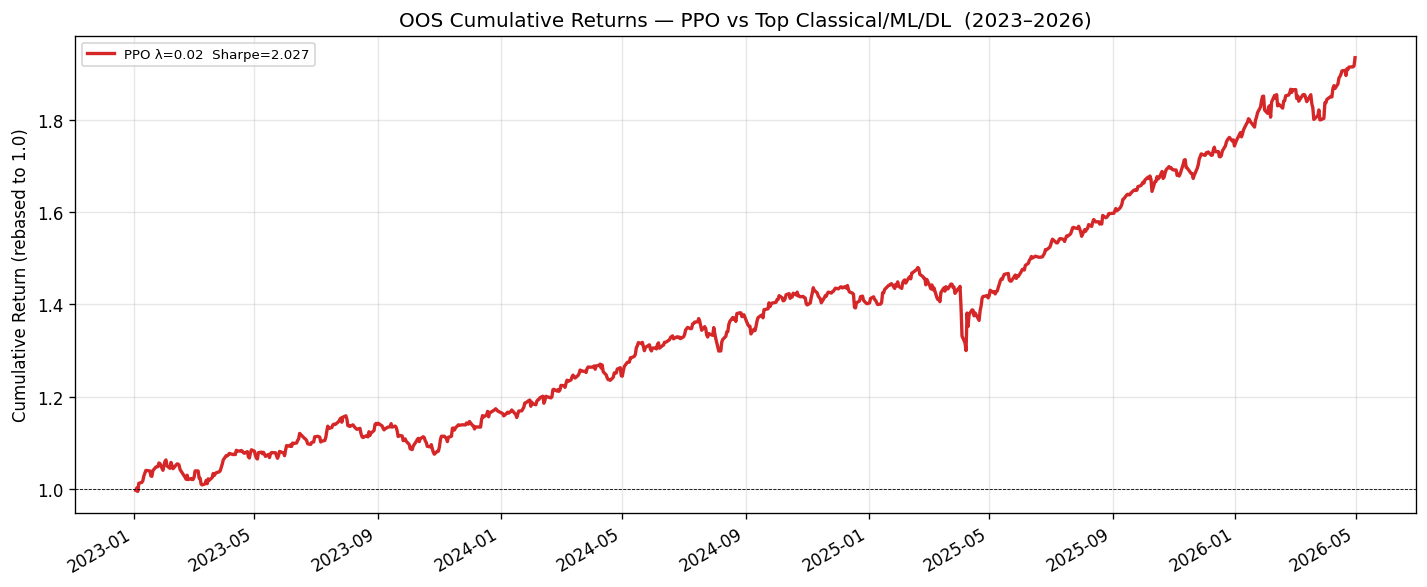

Saved: /content/next-gen-aiam/results/rl/n29_ppo/figures/equity_curves_ppo.png


In [12]:
# --- Figure 1: equity_curves_ppo.png ---
base_rets_path = ROOT / 'data' / 'cache' / 'portfolio_returns' / '31strategies_29assets_2003_2026.parquet'
try:
    base_rets = pd.read_parquet(base_rets_path)
    base_rets_oos = base_rets.loc[TEST_START:]
    top5_strats   = full_df[~full_df.index.str.startswith('RL')].head(5).index.tolist()
    available     = [s for s in top5_strats if s in base_rets_oos.columns]
    compare_rets  = base_rets_oos[available[:3]] if available else pd.DataFrame()
except Exception:
    compare_rets = pd.DataFrame()

fig, ax = plt.subplots(figsize=(12, 5))
(1 + ret_PPO).cumprod().plot(ax=ax, lw=2, color='tab:red', label=f'PPO λ=0.02  Sharpe={sharpe_PPO:.3f}')

for col in compare_rets.columns:
    sh = ann_sharpe(compare_rets[col])
    (1 + compare_rets[col]).cumprod().plot(ax=ax, lw=1, alpha=0.7, label=f'{col}  ({sh:.3f})')

ax.axhline(1.0, color='black', lw=0.5, ls='--')
ax.set_title('OOS Cumulative Returns — PPO vs Top Classical/ML/DL  (2023–2026)')
ax.set_ylabel('Cumulative Return (rebased to 1.0)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'equity_curves_ppo.png', dpi=150)
plt.show()
print(f'Saved: {FIG_DIR / "equity_curves_ppo.png"}')

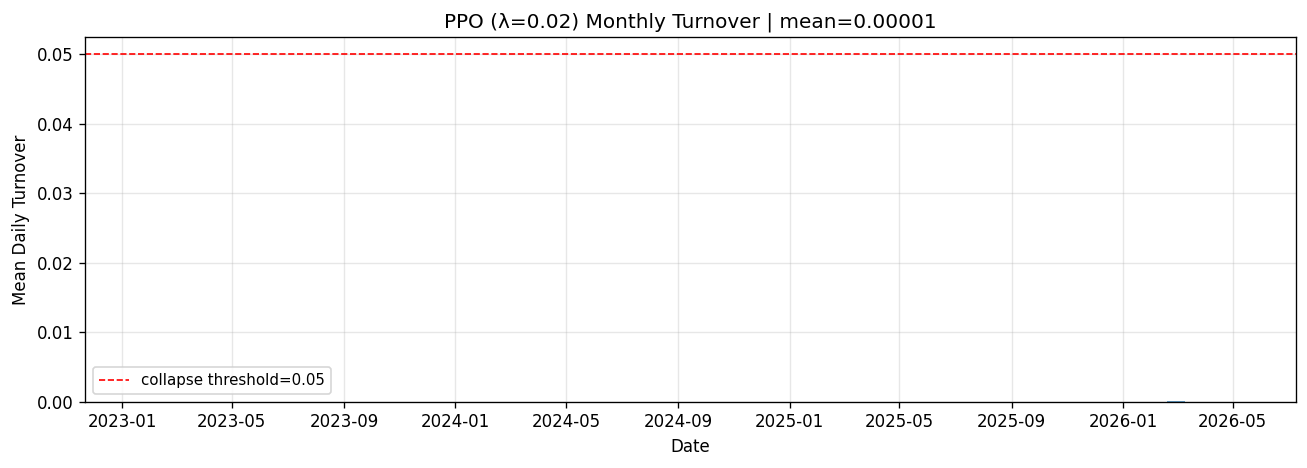

Saved: /content/next-gen-aiam/results/rl/n29_ppo/figures/turnover_ppo.png


In [13]:
# --- Figure 2: turnover_ppo.png ---
fig, ax = plt.subplots(figsize=(11, 4))
to = weights_PPO.diff().abs().sum(axis=1).fillna(0)
to_monthly = to.resample('ME').mean()
ax.bar(to_monthly.index, to_monthly.values, width=20, alpha=0.7, color='tab:blue')
ax.axhline(TO_THRESH, color='red', lw=1, ls='--', label=f'collapse threshold={TO_THRESH}')
ax.set_title(f'PPO (λ=0.02) Monthly Turnover | mean={to.mean():.5f}')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Daily Turnover')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'turnover_ppo.png', dpi=150)
plt.show()
print(f'Saved: {FIG_DIR / "turnover_ppo.png"}')

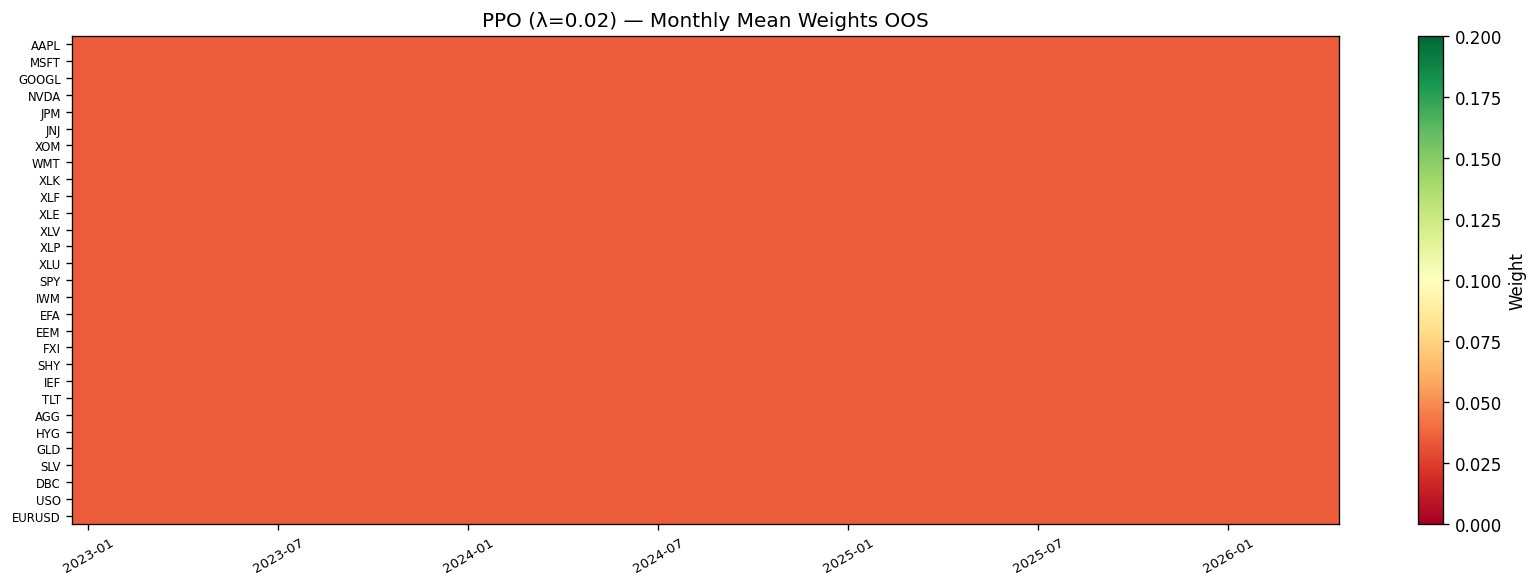

Saved: /content/next-gen-aiam/results/rl/n29_ppo/figures/weight_heatmap_ppo.png


In [14]:
# --- Figure 3: weight_heatmap_ppo.png ---
fig, ax = plt.subplots(figsize=(14, 5))
w_monthly = weights_PPO.resample('ME').mean()
im = ax.imshow(w_monthly.T.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.2)
ax.set_yticks(range(N_ASSETS))
ax.set_yticklabels([a.split('.')[0] for a in ASSETS], fontsize=7)
n_ticks = max(1, len(w_monthly) // 6)
ax.set_xticks(range(0, len(w_monthly), n_ticks))
ax.set_xticklabels(
    [d.strftime('%Y-%m') for d in w_monthly.index[::n_ticks]], rotation=30, fontsize=8
)
fig.colorbar(im, ax=ax, label='Weight')
ax.set_title('PPO (λ=0.02) — Monthly Mean Weights OOS')
fig.tight_layout()
fig.savefig(FIG_DIR / 'weight_heatmap_ppo.png', dpi=150)
plt.show()
print(f'Saved: {FIG_DIR / "weight_heatmap_ppo.png"}')

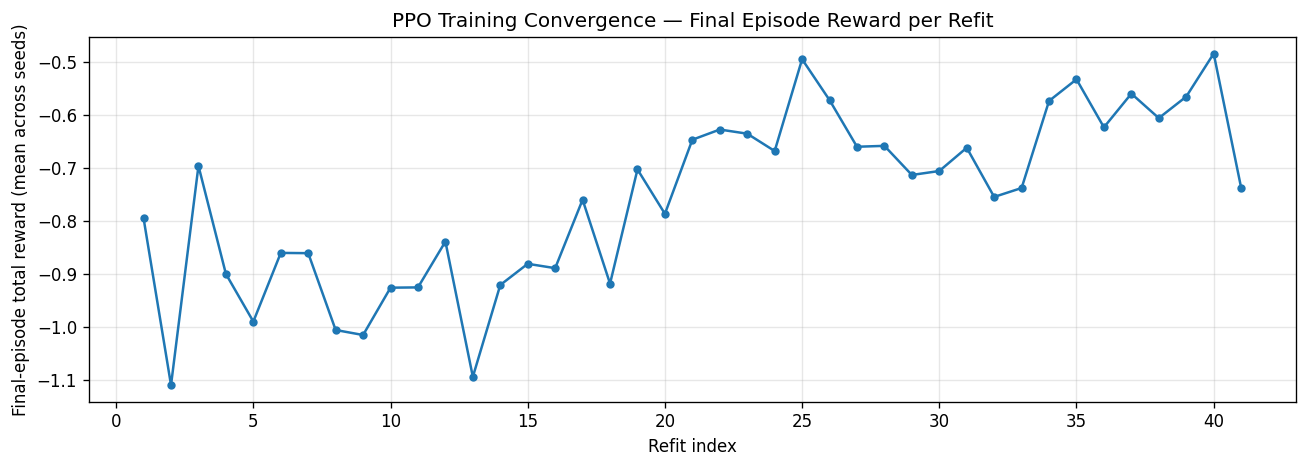

Saved: /content/next-gen-aiam/results/rl/n29_ppo/figures/training_reward_ppo.png


In [15]:
# --- Figure 4: training_reward_ppo.png — final-episode reward across refits ---
final_rewards = [
    np.mean([h.episode_rewards[-1] for h in rr.histories if h.episode_rewards])
    for rr in wf_PPO.refit_results
]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, len(final_rewards)+1), final_rewards, marker='o', ms=4)
ax.set_xlabel('Refit index')
ax.set_ylabel('Final-episode total reward (mean across seeds)')
ax.set_title('PPO Training Convergence — Final Episode Reward per Refit')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'training_reward_ppo.png', dpi=150)
plt.show()
print(f'Saved: {FIG_DIR / "training_reward_ppo.png"}')

## §11 Summary

In [16]:
ppo_rank = list(full_df.index).index('RL(PPO,lam=0.02)') + 1
reinforce_rank_002 = list(full_df.index).index('RL(REINFORCE,lam=0.02)') + 1

print('=' * 70)
print('SESSION 4d SUMMARY — PPO ARMOR RUN')
print('=' * 70)
print(f'Universe     : {N_ASSETS} assets, 2003-2026')
print(f'Methodology  : PPO (clip_eps=0.2, GAE λ=0.95), monthly walk-forward')
print(f'Config       : 1 (λ_risk=0.02)  |  Seeds: {len(SEEDS)}  |  Episodes: {EPISODES}')
print(f'K epochs/fit : 4')
print(f'Max steps    : {MAX_STEPS} ({"full rollout" if MAX_STEPS is None else "truncated"})')
print(f'Total fits   : {len(SEEDS) * len(wf_PPO.refit_results)}')
print()
print(f'PPO (λ=0.02)        : Sharpe={sharpe_PPO:.4f}  AnnRet={annret_PPO:.4f}  '
      f'AnnVol={annvol_PPO:.4f}  MaxDD={maxdd_PPO:.4f}  Rank={ppo_rank}/{len(full_df)}')
print(f'REINFORCE (λ=0.02)  : Sharpe=2.0255  (from 4c Colab)  Rank={reinforce_rank_002}/{len(full_df)}')
print(f'ML bar (reference)  : 2.579  (MSR Ensemble μ̂)')
print()
print(f'Collapse verdict    : {"STATIC_COLLAPSE_DETECTED" if collapsed_PPO else "DYNAMIC_POLICY_DETECTED"}')
print(f'PPO mean_turnover   : {mean_to_PPO:.6f}')
print(f'PPO weight_std      : {wstd_PPO:.6f}')
print('=' * 70)

SESSION 4d SUMMARY — PPO ARMOR RUN
Universe     : 29 assets, 2003-2026
Methodology  : PPO (clip_eps=0.2, GAE λ=0.95), monthly walk-forward
Config       : 1 (λ_risk=0.02)  |  Seeds: 5  |  Episodes: 200
K epochs/fit : 4
Max steps    : None (full rollout)
Total fits   : 205

PPO (λ=0.02)        : Sharpe=2.0267  AnnRet=0.2206  AnnVol=0.1009  MaxDD=-0.1216  Rank=26/40
REINFORCE (λ=0.02)  : Sharpe=2.0255  (from 4c Colab)  Rank=28/40
ML bar (reference)  : 2.579  (MSR Ensemble μ̂)

Collapse verdict    : STATIC_COLLAPSE_DETECTED
PPO mean_turnover   : 0.000007
PPO weight_std      : 0.000000


## §12 Artifact Safety — DOWNLOAD BEFORE DISCONNECTING

In [17]:
!cd /content/next-gen-aiam && zip -r /content/ppo_artifacts.zip \
    results/rl/n29_ppo/ \
    data/published/full_comparison_with_rl.csv

print()
print('=' * 60)
print('DOWNLOAD ppo_artifacts.zip from the file panel')
print('(folder icon, left sidebar) → right-click → Download')
print()
print('After download, copy to repo:')
print('  cp -r ppo_artifacts/results/rl/n29_ppo/ ~/Projects/next-gen-aiam/results/rl/')
print('  cp ppo_artifacts/data/published/full_comparison_with_rl.csv \\')
print('     ~/Projects/next-gen-aiam/data/published/')
print('  git add results/rl/n29_ppo/ data/published/full_comparison_with_rl.csv')
print('  git commit --amend --no-edit   # or a follow-up commit')
print('=' * 60)

  adding: results/rl/n29_ppo/ (stored 0%)
  adding: results/rl/n29_ppo/figures/ (stored 0%)
  adding: results/rl/n29_ppo/figures/equity_curves_ppo.png (deflated 10%)
  adding: results/rl/n29_ppo/figures/.gitkeep (stored 0%)
  adding: results/rl/n29_ppo/figures/training_reward_ppo.png (deflated 7%)
  adding: results/rl/n29_ppo/figures/turnover_ppo.png (deflated 22%)
  adding: results/rl/n29_ppo/figures/weight_heatmap_ppo.png (deflated 22%)
  adding: results/rl/n29_ppo/checkpoints/ (stored 0%)
  adding: results/rl/n29_ppo/checkpoints/refit_39_seed_42.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_09_seed_43.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_28_seed_44.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_22_seed_44.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_33_seed_46.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_38_seed_43.pt (deflated 23%)
  adding: results/rl/n29_ppo/checkpoints/refit_

In [18]:
# HTML snapshot of notebook outputs
!jupyter nbconvert --to html \
    /content/next-gen-aiam/notebooks/04g_rl_ppo.ipynb \
    --output /content/04g_rl_ppo.html

print('HTML snapshot: /content/04g_rl_ppo.html — download from file panel')

[NbConvertApp] Converting notebook /content/next-gen-aiam/notebooks/04g_rl_ppo.ipynb to html
[NbConvertApp] Writing 374961 bytes to /content/04g_rl_ppo.html
HTML snapshot: /content/04g_rl_ppo.html — download from file panel
